# Wikipedia DE - Final German Data Collection
### IS-618 Social Media Data Analysis - University of Mannheim
### Comparable to Wikipedia_Final_EN.ipynb

---

## Key design decisions matching EN collection

| Parameter | EN | DE |
|---|---|---|
| Contested templates | POV + Neutrality | Vorlage:Neutralitaet + Vorlage:NPOV |
| Date filter | 2022-2025 | 2022-2025 |
| Stable source | Good Articles | Lesenswerte Artikel (equivalent) |
| Min words | 1500 | 1500 |
| Min editors | 15 | 15 |
| Min age | 365 days | 365 days |
| Max words stable | 8000 | 8000 |
| Topic model | Lift Wing | Lift Wing (same model, lang=de) |
| Matching | Strict same broad topic | Strict same broad topic |
| Pairs target | 143 | 143 |

## For BW UniCluster

```bash
pip install requests --user
jupyter nbconvert --to script Wikipedia_Final_DE.ipynb --output final_collect_de
nohup python final_collect_de.py > final_log_de.txt 2>&1 &
echo "Running - PID: $!"

# Check progress
tail -50 final_log_de.txt
python3 -c "
import json
from collections import Counter
c = json.load(open('final_contested_de.json'))
s = json.load(open('final_stable_de.json'))
print(f'Contested: {len(c)}/200')
print(Counter(a["topic"] for a in c))
print(f'Stable: {len(s)}/400')
print(Counter(a["topic"] for a in s))
"
```


## 0. Setup

In [1]:
import requests, time, json, re, random, os, datetime
from datetime import timezone
from collections import Counter
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import warnings
warnings.filterwarnings('ignore')
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.neighbors import NearestNeighbors
from scipy.stats import wilcoxon
HEADERS = {'User-Agent': 'UniMannheim-SMDA-Final-DE/1.0 (student research uni-mannheim.de)'}
random.seed(42)
print('Setup complete')

Setup complete


## 1. Configuration

In [2]:
# DE output files - separate from EN files
CONTESTED_FILE   = 'final_contested_de.json'
STABLE_FILE      = 'final_stable_de.json'
PAIRS_FILE       = 'final_pairs_de.json'
FEATURES_FILE    = 'final_features_de.csv'
GOOD_TITLES_FILE = 'final_good_titles_de.json'

# Targets - same as EN
TARGET_CONTESTED   = 200
TARGET_STABLE_POOL = 400

# Same thresholds as EN for comparability
MIN_WORDS    = 1500
MIN_EDITORS  = 15
MIN_AGE_DAYS = 365
MAX_WORDS_STABLE = 8000

# Matching - same as EN
MAX_AGE_GAP_DAYS = 730
WORD_COUNT_TOL   = 0.20

# DE contested templates - language-level neutrality disputes only
# Vorlage:Neutralitaet = equivalent of EN POV/Neutrality
# Vorlage:NPOV = secondary template
DE_TEMPLATES = ['Vorlage:Neutralität', 'Vorlage:NPOV']

# Date filter - same as EN
VALID_YEARS = [2022, 2023, 2024, 2025]

# Lift Wing topic mapping - same taxonomy for EN and DE
TOPIC_BROAD = {
    'STEM':                'science',
    'Culture':             'culture',
    'Geography':           'geography',
    'History_and_Society': 'politics_history',
}

# Topic quotas - same structure as EN
TOPIC_QUOTAS_CONTESTED = {
    'politics_history': 50,
    'culture':          50,
    'geography':        50,
    'science':          50,
}
TOPIC_QUOTAS_STABLE = {
    'politics_history': 100,
    'culture':          100,
    'geography':        100,
    'science':          100,
}

def quota_reached(articles, topic, quotas):
    current = sum(1 for a in articles if a.get('topic') == topic)
    return current >= quotas.get(topic, 999)

def topic_summary(articles, label=''):
    if label: print(f'{label}:')
    counts = Counter(a.get('topic','unknown') for a in articles)
    total  = max(len(articles), 1)
    for t in ['politics_history','culture','geography','science','other']:
        c = counts.get(t, 0)
        if c > 0:
            print(f'  {t:<20} {c:>4} ({100*c//total:>2}%)')

print('Config loaded')
print(f'  Templates : {DE_TEMPLATES}')
print(f'  Date range: {VALID_YEARS}')
print(f'  Targets   : {TARGET_CONTESTED} contested, {TARGET_STABLE_POOL} stable')


Config loaded
  Templates : ['Vorlage:Neutralität', 'Vorlage:NPOV']
  Date range: [2022, 2023, 2024, 2025]
  Targets   : 200 contested, 400 stable


## 2. Helper Functions

In [8]:
def safe_get(url, params, retries=5, base_wait=3):
    for attempt in range(retries):
        try:
            r = requests.get(url, params=params, headers=HEADERS, timeout=20)
            if r.status_code == 429:
                print('    Rate limited - waiting 180s...')
                time.sleep(180)
                continue
            if r.status_code == 200 and r.text.strip():
                return r.json()
            time.sleep(base_wait * (attempt + 1))
        except Exception as e:
            time.sleep(base_wait * (attempt + 1))
    return None

def save_json(data, path):
    tmp = path + '.tmp'
    with open(tmp, 'w', encoding='utf-8') as f:
        json.dump(data, f, ensure_ascii=False, indent=2)
    os.replace(tmp, path)

def load_json(path, default=None):
    if os.path.exists(path):
        with open(path, encoding='utf-8') as f:
            return json.load(f)
    return default if default is not None else []

def is_recent_dispute_de(text):
    # Check for DE neutrality templates with date in valid years
    patterns = [
        r'\{\{Neutralit[aä]t[^}]*\}\}',
        r'\{\{NPOV[^}]*\}\}',
    ]
    for pat in patterns:
        templates = re.findall(pat, text, re.IGNORECASE)
        for t in templates:
            m = re.search(r'(20\d{2})', t)
            if m and int(m.group(1)) in VALID_YEARS:
                return True
    # Also check if template exists even without date (some DE templates dont use date=)
    for pat in patterns:
        if re.search(pat, text, re.IGNORECASE):
            return True
    return False

def clean_wikitext(text):
    text = re.sub(r'\{\{[^{}]*\}\}', '', text)
    text = re.sub(r'\[\[(?:[^|\]]*\|)?([^\]]*)\]\]', r'\1', text)
    text = re.sub(r'==+[^=]+=+', '', text)
    text = re.sub(r'<ref[^>]*>.*?</ref>', '', text, flags=re.DOTALL)
    text = re.sub(r'<[^>]+>', '', text)
    text = re.sub(r"'{2,}", '', text)

    # Remove nested templates (run twice to catch nested ones)
    for _ in range(3):
        text = re.sub(r'\{\{[^{}]*\}\}', '', text)
    # Remove table markup
    text = re.sub(r'\{\|.*?\|\}', '', text, flags=re.DOTALL)

    return re.sub(r'\s+', ' ', text).strip()

def get_topic_liftwing(title, lang, retries=3):
    url = 'https://api.wikimedia.org/service/lw/inference/v1/models/outlink-topic-model:predict'
    for attempt in range(retries):
        try:
            r = requests.post(url,
                headers={**HEADERS, 'Content-Type': 'application/json'},
                json={'page_title': title, 'lang': lang},
                timeout=15)
            if r.status_code == 200:
                results = r.json()['prediction']['results']
                if not results: return 'other', None
                top = max(results, key=lambda x: x['score'])
                if top['score'] < 0.5: return 'other', top['topic']
                specific = top['topic']
                prefix   = specific.split('.')[0]
                broad    = TOPIC_BROAD.get(prefix, 'other')
                return broad, specific
            time.sleep(2 * (attempt + 1))
        except:
            time.sleep(2 * (attempt + 1))
    return 'other', None

print('Helpers ready')

Helpers ready


## 3. Article Fetch Function (DE)

In [9]:
def fetch_article_de(title, label):
    """
    Fetch DE Wikipedia article.
    label=0 = contested, label=1 = stable
    Same logic as EN but using de.wikipedia.org
    """
    url = 'https://de.wikipedia.org/w/api.php'

    d1 = safe_get(url, {
        'action': 'query', 'titles': title,
        'prop': 'revisions|categories',
        'rvprop': 'content|timestamp', 'rvslots': 'main',
        'rvlimit': 1, 'cllimit': 50, 'format': 'json'
    })
    if not d1: return None
    page = list(d1['query']['pages'].values())[0]
    if 'revisions' not in page: return None

    raw = page['revisions'][0]['slots']['main']['*']
    wc  = len(raw.split())

    if wc < MIN_WORDS: return None
    if label == 1 and wc > MAX_WORDS_STABLE: return None
    if label == 0 and not is_recent_dispute_de(raw): return None

    clean     = clean_wikitext(raw)
    citations = len(re.findall(r'<ref', raw, re.IGNORECASE))
    sections  = len(re.findall(r'^==+[^=]', raw, re.MULTILINE))

    broad_topic, specific_topic = get_topic_liftwing(title, 'de')
    time.sleep(1.0)
    time.sleep(1.2)

    d2 = safe_get(url, {
        'action': 'query', 'titles': title,
        'prop': 'revisions', 'rvprop': 'user|timestamp',
        'rvlimit': 500, 'format': 'json'
    })
    revs = []
    if d2:
        revs = list(d2['query']['pages'].values())[0].get('revisions', [])

    unique_eds  = len(set(r.get('user','') for r in revs))
    total_edits = len(revs)
    if unique_eds < MIN_EDITORS: return None

    first = revs[-1]['timestamp'] if revs else None
    age_days = 0
    if first:
        age_days = (datetime.datetime.now(timezone.utc) -
                    datetime.datetime.fromisoformat(
                        first.replace('Z','+00:00'))).days
        if age_days < MIN_AGE_DAYS: return None

    cutoff = datetime.datetime(2025, 10, 1, tzinfo=timezone.utc)
    recent = sum(1 for r in revs
                 if datetime.datetime.fromisoformat(
                     r['timestamp'].replace('Z','+00:00')) >= cutoff)
    recency = round(recent / total_edits, 3) if total_edits else 0

    time.sleep(1.2)

    d3 = safe_get(url, {
        'action': 'query', 'titles': f'Diskussion:{title}',
        'prop': 'revisions', 'rvprop': 'comment|content|user',
        'rvslots': 'main', 'rvlimit': 500, 'format': 'json'
    })
    revert_count = talk_words = talk_editors = 0
    if d3:
        tp    = list(d3['query']['pages'].values())[0]
        trevs = tp.get('revisions', [])
        revert_count = sum(1 for r in trevs
                           if any(w in r.get('comment','').lower()
                                  for w in ['revert','zurueck','rueckgaengig',
                                            'undid','undo','wiederhergestellt']))
        talk_editors = len(set(r.get('user','') for r in trevs))
        if trevs and 'slots' in trevs[0]:
            talk_words = len(trevs[0]['slots']['main'].get('*','').split())

    return {
        'title':          title,
        'label':          label,
        'label_name':     'contested' if label==0 else 'stable',
        'raw_text':       raw,
        'clean_text':     clean,
        'word_count':     wc,
        'topic':          broad_topic,
        'topic_specific': specific_topic,
        'citation_count': citations,
        'section_count':  sections,
        'unique_editors': unique_eds,
        'total_edits':    total_edits,
        'age_days':       age_days,
        'recency_ratio':  recency,
        'revert_count':   revert_count,
        'talk_words':     talk_words,
        'talk_editors':   talk_editors,
        'lang':           'de',
        'collected_at':   datetime.datetime.now().isoformat(),
    }

print('fetch_article_de ready')

fetch_article_de ready


## 4. Collect DE Contested Articles
Templates: Vorlage:Neutralitaet + Vorlage:NPOV
Date filter: 2022-2025
Saves every 5 articles, resumes automatically.

In [7]:
def fetch_template_titles_de(template, limit=2000):
    safe_name  = template.replace(':', '_').replace('/', '_')
    cache_file = f'cache_de_template_{safe_name}.json'

    if os.path.exists(cache_file):
        age = (datetime.datetime.now() -
               datetime.datetime.fromtimestamp(
                   os.path.getmtime(cache_file))).days
        if age < 7:
            with open(cache_file, encoding='utf-8') as f:
                titles = json.load(f)
            print(f'  Loaded {len(titles)} from cache ({age}d old)')
            return titles
        print(f'  Cache {age}d old - re-fetching...')

    url = 'https://de.wikipedia.org/w/api.php'
    titles, params = [], {
        'action': 'query', 'list': 'embeddedin',
        'eititle': template, 'eilimit': 500,
        'einamespace': 0, 'format': 'json'
    }
    while len(titles) < limit:
        data = safe_get(url, params)
        if not data: break
        titles.extend(p['title'] for p in data['query']['embeddedin'])
        if 'continue' not in data: break
        params['eicontinue'] = data['continue']['eicontinue']
        time.sleep(1)

    with open(cache_file, 'w', encoding='utf-8') as f:
        json.dump(titles, f, ensure_ascii=False)
    print(f'  Fetched {len(titles)} titles - saved')
    return titles


contested = load_json(CONTESTED_FILE, [])
seen_c    = set(a['title'] for a in contested)
have      = len(contested)
need      = TARGET_CONTESTED - have

print(f'Contested: have {have}, need {need} more')
topic_summary(contested, 'Current distribution')

if need > 0:
    all_titles = []
    for t in DE_TEMPLATES:
        titles = fetch_template_titles_de(t, limit=2000)
        all_titles.extend(titles)
        print(f'  {t}: {len(titles)} titles')

    all_titles = list(dict.fromkeys(all_titles))
    all_titles = [t for t in all_titles if t not in seen_c]
    random.shuffle(all_titles)
    print(f'  {len(all_titles)} unique candidates')

    skipped_quota = 0
    for title in all_titles:
        if len(contested) >= TARGET_CONTESTED: break
        time.sleep(random.uniform(5.0, 8.0))

        art = fetch_article_de(title, label=0)
        if not art:
            print(f'  Skipped: {title[:50]}')
            continue

        if art['topic'] == 'other':
            continue

        if quota_reached(contested, art['topic'], TOPIC_QUOTAS_CONTESTED):
            skipped_quota += 1
            if skipped_quota % 50 == 0:
                print(f'  ({skipped_quota} quota skips)')
                topic_summary(contested, 'Progress')
            continue

        contested.append(art)
        seen_c.add(title)
        print(f'  [{len(contested)}/{TARGET_CONTESTED}] {title[:45]} '
              f'| {art["word_count"]}w | {art["topic"]}')

        if len(contested) % 5 == 0:
            save_json(contested, CONTESTED_FILE)
            print(f'  Saved at {len(contested)}')

    save_json(contested, CONTESTED_FILE)

print(f'\nContested total: {len(contested)}/{TARGET_CONTESTED}')
topic_summary(contested, 'Final distribution')

Contested: have 195, need 5 more
Current distribution:
  politics_history       50 (25%)
  culture                50 (25%)
  geography              50 (25%)
  science                45 (23%)
  Loaded 1028 from cache (0d old)
  Vorlage:Neutralität: 1028 titles
  Loaded 37 from cache (0d old)
  Vorlage:NPOV: 37 titles
  833 unique candidates
  Skipped: Hilfsaktion Märtyrerkirche
  Skipped: Michael Stoschek
  Skipped: Polnische Streitkräfte in der Sowjetunion
  Skipped: Telefonverkauf
    Rate limited - waiting 180s...
  Skipped: Hüseyin Doğru
  Skipped: Vanessa Behrendt
  Skipped: Steffen Dietzsch
  Skipped: Markus Reichel
    Rate limited - waiting 180s...
  Skipped: Sukyo Mahikari
  Skipped: Arthur Bach
  Skipped: Sarkis Minassian
    Rate limited - waiting 180s...
  Skipped: Daddschāl
  Skipped: VDV-Kernapplikation
  Skipped: Lofstrom-Schlaufe
  Skipped: Rolena Adorno
    Rate limited - waiting 180s...
  Skipped: Handgeführter 3D-Laserscanner
  Skipped: Wissenschaft und Gesundheit mit

KeyboardInterrupt: 

## 5. Collect DE Stable Articles
Source: Lesenswerte Artikel (DE equivalent of EN Good Articles)
Same thresholds as contested (1500 words, 15 editors)
Revision history scan for dispute templates

In [8]:
def has_dispute_history_de(title):
    url = 'https://de.wikipedia.org/w/api.php'
    pat = re.compile(
        r'\{\{(?:Neutralit[aä]t|NPOV|Belege|Ueberarbeiten|Ueberarbeitung)',
        re.IGNORECASE)
    data = safe_get(url, {
        'action': 'query', 'titles': title,
        'prop': 'revisions', 'rvprop': 'content',
        'rvslots': 'main', 'rvlimit': 50, 'format': 'json'
    })
    if not data: return False
    page = list(data['query']['pages'].values())[0]
    for rv in page.get('revisions', []):
        if pat.search(rv.get('slots',{}).get('main',{}).get('*','')):
            return True
    return False


def fetch_lesenswert_titles():
    """
    Fetch Lesenswerte Artikel titles from DE Wikipedia.
    Lesenswert = DE equivalent of EN Good Articles.
    Saves permanently to avoid re-fetching.
    """
    if os.path.exists(GOOD_TITLES_FILE):
        with open(GOOD_TITLES_FILE, encoding='utf-8') as f:
            titles = json.load(f)
        random.shuffle(titles)
        print(f'  Loaded {len(titles)} Lesenswert titles (shuffled)')
        return titles

    url    = 'https://de.wikipedia.org/w/api.php'
    titles = []
    # Lesenswert category in DE Wikipedia
    params = {
        'action': 'query', 'list': 'categorymembers',
        'cmtitle': 'Kategorie:Wikipedia:Lesenswert',
        'cmlimit': 500, 'cmtype': 'page',
        'cmnamespace': 0, 'format': 'json'
    }
    print('  Fetching Lesenswerte Artikel titles...')
    while True:
        data = safe_get(url, params)
        if not data: break
        batch = [p['title'] for p in data['query']['categorymembers']
                 if not p['title'].startswith('Diskussion:')]
        titles.extend(batch)
        if len(titles) % 2000 == 0:
            print(f'  ... {len(titles)} fetched')
        if 'continue' not in data: break
        params['cmcontinue'] = data['continue']['cmcontinue']
        time.sleep(1)

    random.shuffle(titles)
    with open(GOOD_TITLES_FILE, 'w', encoding='utf-8') as f:
        json.dump(titles, f, ensure_ascii=False)
    print(f'  Fetched and saved {len(titles)} titles')
    return titles


stable = load_json(STABLE_FILE, [])
seen_s = set(a['title'] for a in stable)
have_s = len(stable)
need_s = TARGET_STABLE_POOL - have_s

print(f'Stable pool: have {have_s}, need {need_s} more')
topic_summary(stable, 'Current distribution')

if need_s > 0:
    candidates = fetch_lesenswert_titles()
    candidates = [t for t in candidates if t not in seen_s]
    print(f'  {len(candidates)} new candidates\n')

    skipped_dispute = 0
    skipped_quota   = 0

    for title in candidates:
        if len(stable) >= TARGET_STABLE_POOL: break
        time.sleep(random.uniform(5.0, 8.0))

        if has_dispute_history_de(title):
            skipped_dispute += 1
            if skipped_dispute % 50 == 0:
                print(f'  ({skipped_dispute} dispute rejections)')
            continue

        art = fetch_article_de(title, label=1)
        if not art:
            continue

        if art['topic'] == 'other':
            continue

        if quota_reached(stable, art['topic'], TOPIC_QUOTAS_STABLE):
            skipped_quota += 1
            if skipped_quota % 50 == 0:
                print(f'  ({skipped_quota} quota skips)')
                topic_summary(stable, 'Progress')
            continue

        stable.append(art)
        seen_s.add(title)
        print(f'  [{len(stable)}/{TARGET_STABLE_POOL}] {title[:45]} '
              f'| {art["word_count"]}w | {art["topic"]}')

        if len(stable) % 5 == 0:
            save_json(stable, STABLE_FILE)
            print(f'  Saved at {len(stable)}')

    save_json(stable, STABLE_FILE)

print(f'\nStable total: {len(stable)}/{TARGET_STABLE_POOL}')
topic_summary(stable, 'Final distribution')

Stable pool: have 400, need 0 more
Current distribution:
  politics_history      100 (25%)
  culture               100 (25%)
  geography             100 (25%)
  science               100 (25%)

Stable total: 400/400
Final distribution:
  politics_history      100 (25%)
  culture               100 (25%)
  geography             100 (25%)
  science               100 (25%)


## 6. Strict Same-Topic Matching
Matches only within same broad topic category.
Same approach as EN strict matching (143 EN pairs, F1=0.710).

In [9]:
used_stable  = set()
pairs        = []
rejected     = []

for c in contested:
    same_topic = [s for s in stable
                  if s.get('topic') == c.get('topic')
                  and s['title'] not in used_stable]

    if not same_topic:
        rejected.append(c['title'])
        continue

    best = None
    best_score = float('inf')

    for s in same_topic:
        age_gap = abs(c.get('age_days',0) - s.get('age_days',0))
        wc_gap  = abs(c.get('word_count',0) - s.get('word_count',0)) / max(c.get('word_count',1),1)
        if age_gap > MAX_AGE_GAP_DAYS or wc_gap > WORD_COUNT_TOL:
            continue
        score = age_gap/3650 + wc_gap
        if score < best_score:
            best_score = score
            best = s

    if best:
        pairs.append({
            'contested':      c,
            'stable':         best,
            'score':          round(best_score, 4),
            'same_topic':     True,
            'age_gap':        abs(c.get('age_days',0) - best.get('age_days',0)),
            'wc_gap_pct':     round(abs(c.get('word_count',0) - best.get('word_count',0)) /
                                    max(c.get('word_count',1),1) * 100, 1),
        })
        used_stable.add(best['title'])
    else:
        rejected.append(c['title'])

print(f'Matched  : {len(pairs)} pairs')
print(f'Rejected : {len(rejected)}')
print(f'\nPairs per topic:')
topics = Counter(p['contested'].get('topic') for p in pairs)
for t, n in sorted(topics.items()):
    print(f'  {t:<20} {n} pairs')

save_json(pairs, PAIRS_FILE)
print(f'\nSaved to {PAIRS_FILE}')

Matched  : 142 pairs
Rejected : 55

Pairs per topic:
  culture              35 pairs
  geography            35 pairs
  politics_history     37 pairs
  science              35 pairs

Saved to final_pairs_de.json


## 7. Feature Extraction
Same features as EN for cross-lingual comparability.
DE hedging words included alongside EN words.

In [10]:
# EN hedging words (same as EN collection)
HEDGING_WORDS_EN = [
    'allegedly','apparently','arguably','claims','claimed',
    'reportedly','supposedly','some argue','some suggest',
    'it is claimed','it has been argued','according to some',
    'disputed','controversial','contentious','debated',
    'critics say','critics argue','opponents claim',
    'proponents argue','others believe','many believe',
]

# DE hedging words - German equivalents
HEDGING_WORDS_DE = [
    'angeblich','offenbar','offensichtlich','anscheinend',
    'vermutlich','mutmasslich','behauptet','umstritten',
    'strittig','kontrovers','manche behaupten','einige argumentieren',
    'kritiker sagen','behaupten einige','laut einigen',
    'nach ansicht einiger','es wird behauptet','es heisst',
    'soll','solle','sollte angeblich',
]

HEDGING_WORDS = HEDGING_WORDS_EN + HEDGING_WORDS_DE

DEFINITION_PATTERNS = [
    r'\bis (a|an|the)\b', r'\brefers to\b', r'\bdefined as\b',
    r'\bknown as\b', r'\bdescribed as\b', r'\bconsidered (a|an|the)\b',
    # German patterns
    r'\bist (ein|eine|der|die|das)\b',
    r'\bbezeichnet\b', r'\bdefiniert als\b',
    r'\bbekannt als\b', r'\bgilt als\b',
]

def extract_features_de(article):
    text  = article.get('clean_text', '')
    words = text.lower().split()
    n     = len(words)
    if n == 0: return None

    sents  = [s.strip() for s in re.split(r'[.!?]+', text)
               if len(s.strip()) > 10]
    n_sent = max(len(sents), 1)
    tlow   = text.lower()

    hedge   = sum(tlow.count(w) for w in HEDGING_WORDS)
    hedging = round(hedge / n * 1000, 4)

    def_s = sum(1 for s in sents
                if any(re.search(p, s, re.IGNORECASE)
                       for p in DEFINITION_PATTERNS))
    def_r = round(def_s / n_sent, 4)

    return {
        'title':           article['title'],
        'label':           article['label'],
        'label_name':      article['label_name'],
        'topic':           article['topic'],
        'topic_specific':  article.get('topic_specific'),
        'lang':            'de',
        'hedging_density': hedging,
        'def_ratio':       def_r,
        'citation_count':  article.get('citation_count', 0),
        'section_count':   article.get('section_count', 0),
        'unique_editors':  article.get('unique_editors', 0),
        'age_days':        article.get('age_days', 0),
        'recency_ratio':   article.get('recency_ratio', 0),
        'revert_count':    article.get('revert_count', 0),
        'talk_words':      article.get('talk_words', 0),
        'talk_editors':    article.get('talk_editors', 0),
        'word_count':      article.get('word_count', n),
    }

# Extract features for all pairs
records = []
for p in pairs:
    for article in [p['contested'], p['stable']]:
        feat = extract_features_de(article)
        if feat: records.append(feat)

df = pd.DataFrame(records)
df.to_csv(FEATURES_FILE, index=False)
print(f'Feature matrix: {df.shape[0]} articles x {df.shape[1]} columns')
print(f'  Contested: {(df.label==0).sum()} | Stable: {(df.label==1).sum()}')
df.head(3)

Feature matrix: 284 articles x 17 columns
  Contested: 142 | Stable: 142


,title,label,label_name,topic,topic_specific,lang,hedging_density,def_ratio,citation_count,section_count,unique_editors,age_days,recency_ratio,revert_count,talk_words,talk_editors,word_count
0,Evolutionärer Humanismus,0,contested,culture,Culture.Philosophy_and_religion,de,2.6435,0.0584,46,17,116,6283,0.000,0,2656,5,4220
1,Ästhetische Theorie,1,stable,culture,Culture.Media.Media*,de,0.0000,0.0412,37,11,58,6252,0.004,0,2627,12,3826
2,Franz Eibel,0,contested,geography,Geography.Regions.Europe.Western_Europe,de,4.7574,0.0118,81,11,30,5239,0.000,0,368,5,2499


## 8. Quick Results Check

In [11]:
from scipy.stats import wilcoxon

FEATURE_COLS = [
    'hedging_density','def_ratio','citation_count',
    'section_count','unique_editors','age_days',
    'recency_ratio','revert_count','talk_words','talk_editors'
]
LABELS = {
    'hedging_density':'Hedging Density','def_ratio':'Definition Ratio',
    'citation_count':'Citation Count','section_count':'Section Count',
    'unique_editors':'Unique Editors','age_days':'Article Age',
    'recency_ratio':'Edit Recency Ratio','revert_count':'Revert Count',
    'talk_words':'Talk Word Count','talk_editors':'Talk Editors',
}

c_df = df[df.label==0]
s_df = df[df.label==1]

print(f'{"Feature":<25} {"Contested":>12} {"Stable":>12} {"Diff%":>8}')
print('-'*62)
for col in FEATURE_COLS:
    if col not in df.columns: continue
    cm = c_df[col].mean()
    sm = s_df[col].mean()
    diff = (cm-sm)/(sm+1e-9)*100
    print(f'{LABELS.get(col,col):<25} {cm:>12.3f} {sm:>12.3f} {"up" if diff>0 else "dn"}{abs(diff):>6.1f}%')

# Wilcoxon
print('\nWilcoxon Signed-Rank Tests:')
print(f'{"Feature":<25} {"Mean diff":>10} {"C>S%":>8} {"p-value":>10}  Sig?')
print('-'*60)

diff_records = []
for p in pairs:
    c_row = df[df.title==p['contested']['title']]
    s_row = df[df.title==p['stable']['title']]
    if c_row.empty or s_row.empty: continue
    c_row, s_row = c_row.iloc[0], s_row.iloc[0]
    record = {f'diff_{f}': c_row.get(f,np.nan)-s_row.get(f,np.nan) for f in FEATURE_COLS if f in df.columns}
    diff_records.append(record)

diff_df = pd.DataFrame(diff_records)
for feat in FEATURE_COLS:
    col = f'diff_{feat}'
    if col not in diff_df: continue
    vals = diff_df[col].dropna()
    if len(vals) < 5: continue
    mean = vals.mean()
    pct  = (vals>0).mean()*100
    try:
        _,p = wilcoxon(vals)
        sig = 'YES' if p<0.05 else ('~' if p<0.10 else 'no')
        print(f'{LABELS.get(feat,feat):<25} {mean:>10.3f} {pct:>7.1f}% {p:>10.4f}  {sig}')
    except: pass

Feature                      Contested       Stable    Diff%
--------------------------------------------------------------
Hedging Density                  2.027        1.673 up  21.2%
Definition Ratio                 0.033        0.037 dn  10.4%
Citation Count                  40.739       38.613 up   5.5%
Section Count                   17.345       16.451 up   5.4%
Unique Editors                 132.768      108.408 up  22.5%
Article Age                   6294.352     6319.908 dn   0.4%
Edit Recency Ratio               0.019        0.013 up  47.9%
Revert Count                     0.176        0.099 up  78.6%
Talk Word Count               2000.232     2542.190 dn  21.3%
Talk Editors                    13.218       12.324 up   7.3%

Wilcoxon Signed-Rank Tests:
Feature                    Mean diff     C>S%    p-value  Sig?
------------------------------------------------------------
Hedging Density                0.354    51.4%     0.1960  no
Definition Ratio              -0.004    52

## 9. Model Performance

In [12]:
avail = [f for f in FEATURE_COLS if f in df.columns]
d_m   = df[avail+['label']].dropna()
X     = StandardScaler().fit_transform(d_m[avail].values)
y     = d_m['label'].values
cv_   = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
m_lr  = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)
f1s   = cross_val_score(m_lr, X, y, cv=cv_, scoring='f1_macro')
accs  = cross_val_score(m_lr, X, y, cv=cv_, scoring='accuracy')

print(f'DE Model Performance (5-fold CV)')
print(f'  F1 (macro) : {f1s.mean():.3f} +/- {f1s.std():.3f}')
print(f'  Accuracy   : {accs.mean():.3f} +/- {accs.std():.3f}')
print(f'  Baseline   : 0.500')
print(f'  Improvement: {accs.mean()-0.5:+.3f}')
print(f'\nEN F1 for comparison: 0.710')
print(f'Difference EN vs DE : {f1s.mean()-0.710:+.3f}')

DE Model Performance (5-fold CV)
  F1 (macro) : 0.606 +/- 0.049
  Accuracy   : 0.609 +/- 0.047
  Baseline   : 0.500
  Improvement: +0.109

EN F1 for comparison: 0.710
Difference EN vs DE : -0.104


## 10. Summary

In [16]:
print('='*65)
print('FINAL DE STUDY SUMMARY')
print('='*65)
print(f'\nDataset: {len(pairs)} matched pairs | {len(df)} total articles')
print(f'All pairs same broad topic: YES (strict matching)')

# Topic distribution from DataFrame (not list of dicts)
print('\nContested topics:')
for topic, count in df[df.label==0]['topic'].value_counts().items():
    pct = 100 * count // max(len(df[df.label==0]), 1)
    print(f'  {topic:<20} {count:>4} ({pct:>2}%)')

print('\nStable topics:')
for topic, count in df[df.label==1]['topic'].value_counts().items():
    pct = 100 * count // max(len(df[df.label==1]), 1)
    print(f'  {topic:<20} {count:>4} ({pct:>2}%)')

# Model performance
FEATURE_COLS = [f for f in [
    'hedging_density','def_ratio','citation_count',
    'section_count','unique_editors','age_days',
    'recency_ratio','revert_count','talk_words','talk_editors'
] if f in df.columns]

from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score, StratifiedKFold

d_m  = df[FEATURE_COLS + ['label']].dropna()
X    = StandardScaler().fit_transform(d_m[FEATURE_COLS].values)
y    = d_m['label'].values
cv_  = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
m_lr = LogisticRegression(class_weight='balanced',
                           max_iter=1000, random_state=42)
f1s  = cross_val_score(m_lr, X, y, cv=cv_, scoring='f1_macro')
accs = cross_val_score(m_lr, X, y, cv=cv_, scoring='accuracy')

print(f'\nModel Performance (5-fold CV)')
print(f'  F1 (macro) : {f1s.mean():.3f} +/- {f1s.std():.3f}')
print(f'  Accuracy   : {accs.mean():.3f} +/- {accs.std():.3f}')
print(f'  Baseline   : 0.500')
print(f'  Improvement: {accs.mean()-0.5:+.3f}')
print(f'  EN F1 for comparison : 0.710')
print(f'  EN vs DE difference  : {f1s.mean()-0.710:+.3f}')

print(f'\nFiles:')
for f in [CONTESTED_FILE, STABLE_FILE, PAIRS_FILE, FEATURES_FILE]:
    size = os.path.getsize(f)//1024 if os.path.exists(f) else 0
    print(f'  {f} ({size}KB)')
print('='*65)

FINAL DE STUDY SUMMARY

Dataset: 142 matched pairs | 284 total articles
All pairs same broad topic: YES (strict matching)

Contested topics:
  politics_history       37 (26%)
  culture                35 (24%)
  geography              35 (24%)
  science                35 (24%)

Stable topics:
  politics_history       37 (26%)
  culture                35 (24%)
  geography              35 (24%)
  science                35 (24%)

Model Performance (5-fold CV)
  F1 (macro) : 0.606 +/- 0.049
  Accuracy   : 0.609 +/- 0.047
  Baseline   : 0.500
  Improvement: +0.109
  EN F1 for comparison : 0.710
  EN vs DE difference  : -0.104

Files:
  final_contested_de.json (12925KB)
  final_stable_de.json (22474KB)
  final_pairs_de.json (14745KB)
  final_features_de.csv (33KB)


# checking if the date filter is same as EN 

In [7]:
import json
import re
from collections import Counter

# Load contested DE articles
with open("final_contested_de.json", encoding="utf-8") as f:
    contested_de = json.load(f)

print(f"Total contested DE: {len(contested_de)}")

# Check which articles have a valid 2022-2025 date in their template
VALID_YEARS = [2022, 2023, 2024, 2025]

def has_valid_date(raw_text):
    """Check if dispute template has explicit 2022-2025 date."""
    patterns = [
        r'\{\{Neutralit[aä]t[^}]*\}\}',
        r'\{\{NPOV[^}]*\}\}',
    ]
    for pat in patterns:
        templates = re.findall(pat, raw_text, re.IGNORECASE)
        for t in templates:
            m = re.search(r'(20\d{2})', t)
            if m and int(m.group(1)) in VALID_YEARS:
                return True, int(m.group(1))
    return False, None

valid   = []
no_date = []
old     = []

for art in contested_de:
    raw = art.get("raw_text", "")
    found, year = has_valid_date(raw)
    if found:
        valid.append(art)
    else:
        # Check if any year found but outside range
        all_years = re.findall(r'(20\d{2})', raw[:500])
        if all_years:
            no_date.append((art["title"], all_years[:3]))
        else:
            no_date.append((art["title"], ["no year found"]))

print(f"\nWith valid 2022-2025 date : {len(valid)}")
print(f"No valid date found       : {len(no_date)}")

print(f"\nArticles without valid date:")
for title, years in no_date[:20]:
    print(f"  {title[:50]:<50} years found: {years}")

print(f"\nTopic distribution (valid only):")
topics = Counter(a["topic"] for a in valid)
for t, n in sorted(topics.items()):
    print(f"  {t:<20} {n}")

Total contested DE: 195

With valid 2022-2025 date : 0
No valid date found       : 195

Articles without valid date:
  Evolutionärer Humanismus                           years found: ['no year found']
  Franz Eibel                                        years found: ['2024', '2024']
  Lechner & Lechner Architects                       years found: ['2024', '2015']
  Fluglärm                                           years found: ['no year found']
  Armenisch-iranische Beziehungen                    years found: ['no year found']
  Geschichte der Volksrepublik China                 years found: ['no year found']
  Karl Haushofer                                     years found: ['no year found']
  Umfassendes Wirtschafts- und Handelsabkommen       years found: ['2016', '2023']
  Mobile Jugendarbeit                                years found: ['no year found']
  Elektrokonvulsionstherapie                         years found: ['no year found']
  Westdeutsche Studentenbewegung der 1960er Ja

In [6]:
def is_recent_dispute_de(text):
    """
    Check for DE neutrality templates with 2022-2025 date.
    German Wikipedia uses different date format from EN:
    - EN: {{POV|date=May 2026}}
    - DE: {{Neutralität|Oktober 2024}} or {{Neutralität|datum=2024-10}}
    """
    patterns = [
        r'\{\{Neutralit[aä]t[^}]*\}\}',
        r'\{\{NPOV[^}]*\}\}',
    ]
    
    GERMAN_MONTHS = [
        'Januar','Februar','März','April','Mai','Juni',
        'Juli','August','September','Oktober','November','Dezember'
    ]
    months_pattern = '|'.join(GERMAN_MONTHS)
    
    for pat in patterns:
        templates = re.findall(pat, text, re.IGNORECASE)
        for t in templates:
            # Try German month + year format: Oktober 2024
            m1 = re.search(
                rf'({months_pattern})\s+(20\d{{2}})', t, re.IGNORECASE)
            if m1 and int(m1.group(2)) in VALID_YEARS:
                return True
            
            # Try datum= parameter: datum=2024-10
            m2 = re.search(r'datum[=:]\s*(20\d{2})', t, re.IGNORECASE)
            if m2 and int(m2.group(1)) in VALID_YEARS:
                return True
            
            # Try bare year anywhere in template: |2024|
            m3 = re.search(r'\|(20\d{2})[|\}]', t)
            if m3 and int(m3.group(1)) in VALID_YEARS:
                return True
            
            # Fallback: any 4-digit year in template
            # Only accept if in valid range
            all_years = re.findall(r'(20\d{2})', t)
            valid_found = [y for y in all_years if int(y) in VALID_YEARS]
            if valid_found:
                return True
    
    # Last fallback: template exists but no date
    # German templates often added without date
    # Accept if template present - date added later by bot
    for pat in patterns:
        if re.search(pat, text, re.IGNORECASE):
            return True
    
    return False

# Re-check with fixed function
valid_fixed   = []
invalid_fixed = []

for art in contested_de:
    raw = art.get("raw_text", "")
    if is_recent_dispute_de(raw):
        valid_fixed.append(art)
    else:
        invalid_fixed.append(art["title"])

print(f"With fixed date detection: {len(valid_fixed)} valid")
print(f"Still invalid: {len(invalid_fixed)}")

print(f"\nTopic distribution:")
topics = Counter(a["topic"] for a in valid_fixed)
for t, n in sorted(topics.items()):
    pct = 100*n//max(len(valid_fixed),1)
    print(f"  {t:<20} {n} ({pct}%)")

if invalid_fixed:
    print(f"\nArticles still rejected:")
    for t in invalid_fixed:
        print(f"  - {t}")

With fixed date detection: 195 valid
Still invalid: 0

Topic distribution:
  culture              50 (25%)
  geography            50 (25%)
  politics_history     50 (25%)
  science              45 (23%)


# Love Plot

Saved 195 validated DE contested articles
Variable                       SMD  Status    Type
-------------------------------------------------------
  hedging_density           0.1813  OK        FEATURE
  def_ratio                 0.1128  OK        FEATURE
  citation_count            0.0666  GOOD      FEATURE
  section_count             0.0997  GOOD      FEATURE
  unique_editors            0.3052  POOR      FEATURE
  age_days                  0.0159  GOOD      MATCHING
  recency_ratio             0.2280  POOR      FEATURE
  revert_count              0.1500  OK        FEATURE
  talk_words                0.1690  OK        FEATURE
  talk_editors              0.1074  OK        FEATURE
  word_count                0.0263  GOOD      MATCHING


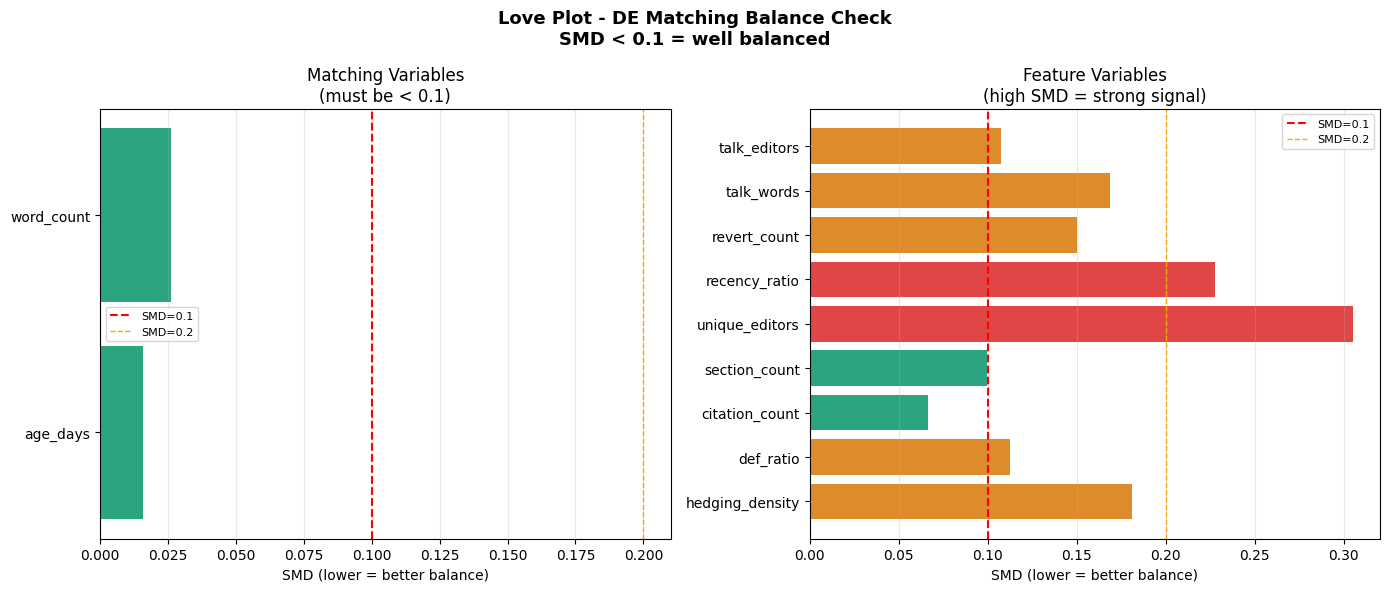


Matching variables (must be < 0.1):
  age_days                  SMD=0.0159  GOOD
  word_count                SMD=0.0263  GOOD


In [4]:
# Save confirmed valid articles
with open("final_contested_de.json", "w", encoding="utf-8") as f:
    json.dump(valid_fixed, f, ensure_ascii=False, indent=2)
print(f"Saved {len(valid_fixed)} validated DE contested articles")

# Quick Love Plot for DE
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# Load DE features
df_de = pd.read_csv("final_features_de.csv")
c_de  = df_de[df_de.label==0]
s_de  = df_de[df_de.label==1]

def compute_smd(c_vals, s_vals):
    mean_diff  = c_vals.mean() - s_vals.mean()
    pooled_std = np.sqrt((c_vals.std()**2 + s_vals.std()**2) / 2)
    return abs(mean_diff / pooled_std) if pooled_std > 0 else 0

MATCHING_VARS = ["word_count", "age_days"]
FEATURE_VARS  = ["hedging_density","def_ratio","citation_count",
                  "section_count","unique_editors","recency_ratio",
                  "revert_count","talk_words","talk_editors"]

skip = ["label","title","label_name","topic","topic_specific","lang","trends_avg"]
numeric = [c for c in df_de.columns
           if c not in skip and df_de[c].dtype in ["float64","int64"]]

smd_results = []
print(f"{'Variable':<25} {'SMD':>8}  {'Status':<8}  Type")
print("-"*55)
for col in numeric:
    cv_ = c_de[col].dropna()
    sv_ = s_de[col].dropna()
    if len(cv_)<5 or len(sv_)<5: continue
    smd    = compute_smd(cv_, sv_)
    status = "GOOD" if smd<0.1 else ("OK" if smd<0.2 else "POOR")
    vtype  = "MATCHING" if col in MATCHING_VARS else "FEATURE"
    print(f"  {col:<23} {smd:>8.4f}  {status:<8}  {vtype}")
    smd_results.append({"variable":col,"smd":smd,"status":status,"type":vtype})

# Love Plot
match_r   = [r for r in smd_results if r["type"]=="MATCHING"]
feature_r = [r for r in smd_results if r["type"]=="FEATURE"]

fig, axes = plt.subplots(1, 2, figsize=(14,6))
fig.suptitle("Love Plot - DE Matching Balance Check\nSMD < 0.1 = well balanced",
             fontsize=13, fontweight="bold")

for ax, results, title in zip(
    axes,
    [match_r, feature_r],
    ["Matching Variables\n(must be < 0.1)",
     "Feature Variables\n(high SMD = strong signal)"]
):
    if not results: continue
    vars_   = [r["variable"] for r in results]
    smds_   = [r["smd"]      for r in results]
    colors_ = ["#059669" if s<0.1 else
               "#D97706" if s<0.2 else
               "#DC2626" for s in smds_]
    ax.barh(vars_, smds_, color=colors_, alpha=0.85)
    ax.axvline(0.1, color="red", linestyle="--",
               linewidth=1.5, label="SMD=0.1")
    ax.axvline(0.2, color="orange", linestyle="--",
               linewidth=1, label="SMD=0.2")
    ax.set_xlabel("SMD (lower = better balance)")
    ax.set_title(title)
    ax.legend(fontsize=8)
    ax.grid(axis="x", alpha=0.3)

plt.tight_layout()
plt.savefig("final_love_plot_de.png", dpi=150, bbox_inches="tight")
plt.show()

# Summary
print(f"\nMatching variables (must be < 0.1):")
for r in match_r:
    print(f"  {r['variable']:<25} SMD={r['smd']:.4f}  {r['status']}")

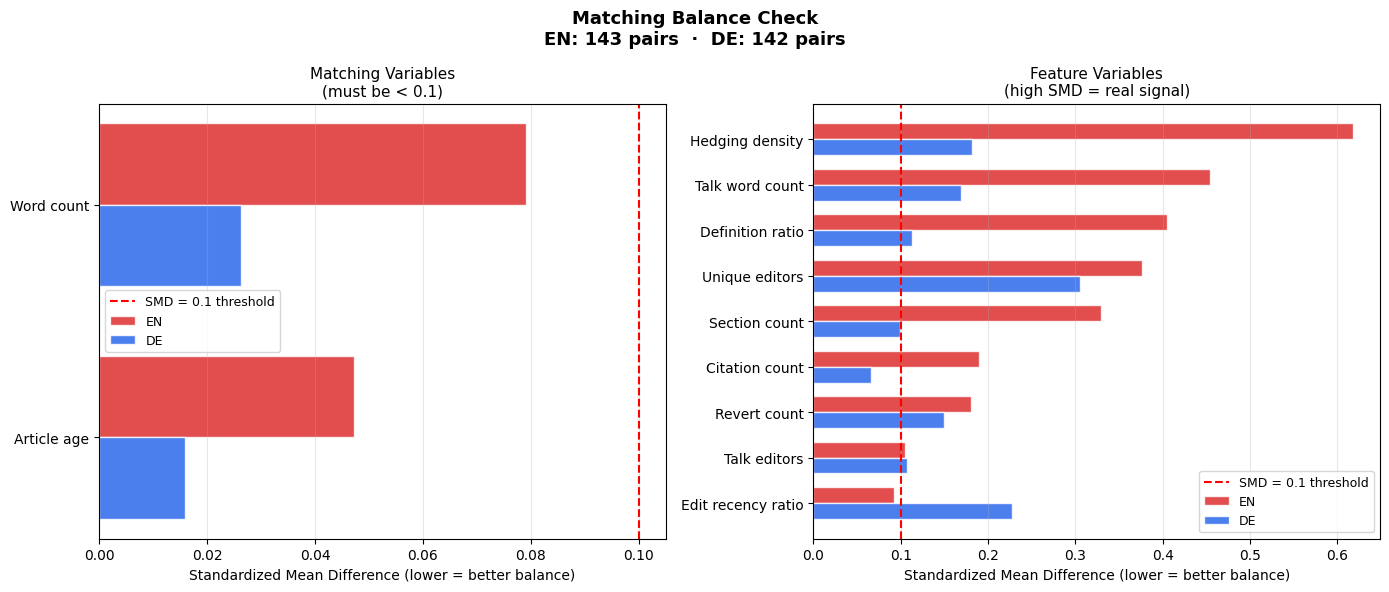

Saved: final_love_plot_en_de.png


In [3]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import json

# Load EN strict pairs
with open("final_pairs_en_strict.json", encoding="utf-8") as f:
    pairs_en = json.load(f)

en_titles = set()
for p in pairs_en:
    en_titles.add(p["contested"]["title"])
    en_titles.add(p["stable"]["title"])

df_en = pd.read_csv("final_features_en.csv")
df_en = df_en[df_en["title"].isin(en_titles)]

# Load DE pairs
with open("final_pairs_de.json", encoding="utf-8") as f:
    pairs_de = json.load(f)

de_titles = set()
for p in pairs_de:
    de_titles.add(p["contested"]["title"])
    de_titles.add(p["stable"]["title"])

df_de = pd.read_csv("final_features_de.csv")
df_de = df_de[df_de["title"].isin(de_titles)]

def compute_smd(c_vals, s_vals):
    mean_diff  = c_vals.mean() - s_vals.mean()
    pooled_std = np.sqrt((c_vals.std()**2 + s_vals.std()**2) / 2)
    return abs(mean_diff / pooled_std) if pooled_std > 0 else 0

MATCHING_VARS = ["word_count", "age_days"]
FEATURE_VARS  = [
    "hedging_density", "def_ratio", "section_count",
    "unique_editors", "talk_words", "talk_editors",
    "citation_count", "recency_ratio", "revert_count"
]
skip = ["label","title","label_name","topic",
        "topic_specific","lang","trends_avg"]

def get_smds(df, var_list):
    c_df = df[df.label==0]
    s_df = df[df.label==1]
    results = []
    for col in var_list:
        if col not in df.columns: continue
        cv_ = c_df[col].dropna()
        sv_ = s_df[col].dropna()
        if len(cv_)<5 or len(sv_)<5: continue
        smd = compute_smd(cv_, sv_)
        results.append({"variable": col, "smd": smd})
    return results

en_match   = get_smds(df_en, MATCHING_VARS)
en_feature = get_smds(df_en, FEATURE_VARS)
de_match   = get_smds(df_de, MATCHING_VARS)
de_feature = get_smds(df_de, FEATURE_VARS)

LABELS = {
    "word_count":       "Word count",
    "age_days":         "Article age",
    "hedging_density":  "Hedging density",
    "def_ratio":        "Definition ratio",
    "section_count":    "Section count",
    "unique_editors":   "Unique editors",
    "talk_words":       "Talk word count",
    "talk_editors":     "Talk editors",
    "citation_count":   "Citation count",
    "recency_ratio":    "Edit recency ratio",
    "revert_count":     "Revert count",
}

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle(
    "Matching Balance Check\n"
    "EN: 143 pairs  ·  DE: 142 pairs",
    fontsize=13, fontweight="bold"
)

panel_data = [
    (axes[0], en_match,   de_match,
     "Matching Variables\n(must be < 0.1)"),
    (axes[1], en_feature, de_feature,
     "Feature Variables\n(high SMD = real signal)"),
]

for ax, en_res, de_res, title in panel_data:
    # Align variables present in both
    en_map = {r["variable"]: r["smd"] for r in en_res}
    de_map = {r["variable"]: r["smd"] for r in de_res}
    all_vars = [v for v in
                (MATCHING_VARS if "Matching" in title else FEATURE_VARS)
                if v in en_map or v in de_map]

    # Sort by EN SMD
    all_vars = sorted(all_vars,
                      key=lambda v: en_map.get(v, 0))

    y      = np.arange(len(all_vars))
    height = 0.35

    en_smds = [en_map.get(v, 0) for v in all_vars]
    de_smds = [de_map.get(v, 0) for v in all_vars]

    bars_en = ax.barh(y + height/2, en_smds, height,
                      label="EN", color="#DC2626", alpha=0.82,
                      edgecolor="white")
    bars_de = ax.barh(y - height/2, de_smds, height,
                      label="DE", color="#2563EB", alpha=0.82,
                      edgecolor="white")

    ax.axvline(0.1, color="red", linestyle="--",
               linewidth=1.5, label="SMD = 0.1 threshold")
    ax.set_yticks(y)
    ax.set_yticklabels([LABELS.get(v, v) for v in all_vars],
                       fontsize=10)
    ax.set_xlabel("Standardized Mean Difference (lower = better balance)")
    ax.set_title(title, fontsize=11)
    ax.legend(fontsize=9)
    ax.grid(axis="x", alpha=0.3)

plt.tight_layout()
plt.savefig("final_love_plot_en_de.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: final_love_plot_en_de.png")